In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from datetime import datetime

In [84]:
file_path = 'NEW__ RFQ US Rates - Bonds Only (July - Sept 24) - Blockhouse.xlsx'
df = pd.read_excel(file_path)
df

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,SettlementDays,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket
0,2024-09-30,66FA7D45432800D20002,Client8,Done,OFFTHERUN,100000000,100000000,100000000,100000000,100000000,...,1,2024-10-01,T+1,2024-09-30 06:28:00,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y
1,2024-09-30,TRSY_20240930_15961,Client9,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,2100000,2100000,...,1,2024-10-01,T+1,2024-09-30 16:00:00,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y
2,2024-09-30,TRSY_20240930_314,Client9,Done,ONTHERUN,53000000,53000000,53000000,53000000,53000000,...,1,2024-10-01,T+1,2024-09-30 15:46:00,2024-09-30 15:46:00,1,0.07,50+M,7-10 YR,7y-10y
3,2024-09-30,66FAEA57432800020001,Client41,Done,OFFTHERUN,500000,500000,500000,500000,500000,...,1,2024-10-01,T+1,2024-09-30 14:14:00,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos
4,2024-09-30,66FAC35D455C00210006,Client139,Done,OFFTHERUN,1058000,1058000,1058000,1058000,1058000,...,1,2024-10-01,T+1,2024-09-30 11:27:00,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40825,2024-07-01,E682EBF3454C00010001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 13:48:00,2024-07-01 13:50:00,1,0.03,10-25M,5-7 YR,3y-5y
40826,2024-07-01,E682D1C745CC000A0001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 11:56:00,2024-07-01 11:58:00,1,0.06,25-50M,5-7 YR,3y-5y
40827,2024-07-01,E682C785454C00010001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 11:13:00,2024-07-01 11:14:00,1,0.03,25-50M,5-7 YR,3y-5y
40828,2024-07-01,E682AFF2454C000C0001,Client736,CustomerTimeOut,"OFFTHERUN,DOUBLEOLDS",0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 09:32:00,2024-07-01 09:34:00,1,0.04,10-25M,5-7 YR,3y-5y


In [85]:
df = df[::-1]
df = df.reset_index(drop=True)

df = df[df["InstrumentSubGroup"] == "ONTHERUN"]

In [86]:
missing_values = df.isnull().sum()
missing_values[:20]

EventDate                  0
Id                         0
Client                     0
RFQStatus                  0
InstrumentSubGroup         0
Mkt Traded Vol             0
Market Traded Vol (USD)    0
Our Traded Vol             0
Our Traded Vol (USD)       0
TiedWonVol                 0
Num of Dealers             0
Trader                     0
Sales                      0
Covered Vol                0
ActionStr                  0
Tier                       0
InstrumentCode             0
InstrumentDescription      0
AssetClass                 0
Market                     0
dtype: int64

In [87]:
missing_values[20:]

LegNo                          0
Maturity Date                  0
RFQNumberOfQuotes              0
Buy/Sell                       0
Best Bid Price                 0
Mid Price                      0
Best Ask Price                 0
Deal Value                     0
AwayFromMid                    0
TickIdentifier               111
Deal Spread                    0
Cover                          0
CoverPnL                       0
SettlementDays                 0
SettlementDate                 0
SettlementStops                0
RFQ CreateTime                 0
RFQ ClosedTime                 0
AnAutoReplyRFQs                0
First Response Time (Sec)      0
TradeSizeBucket                0
Sector                         0
MaturityBucket                 0
dtype: int64

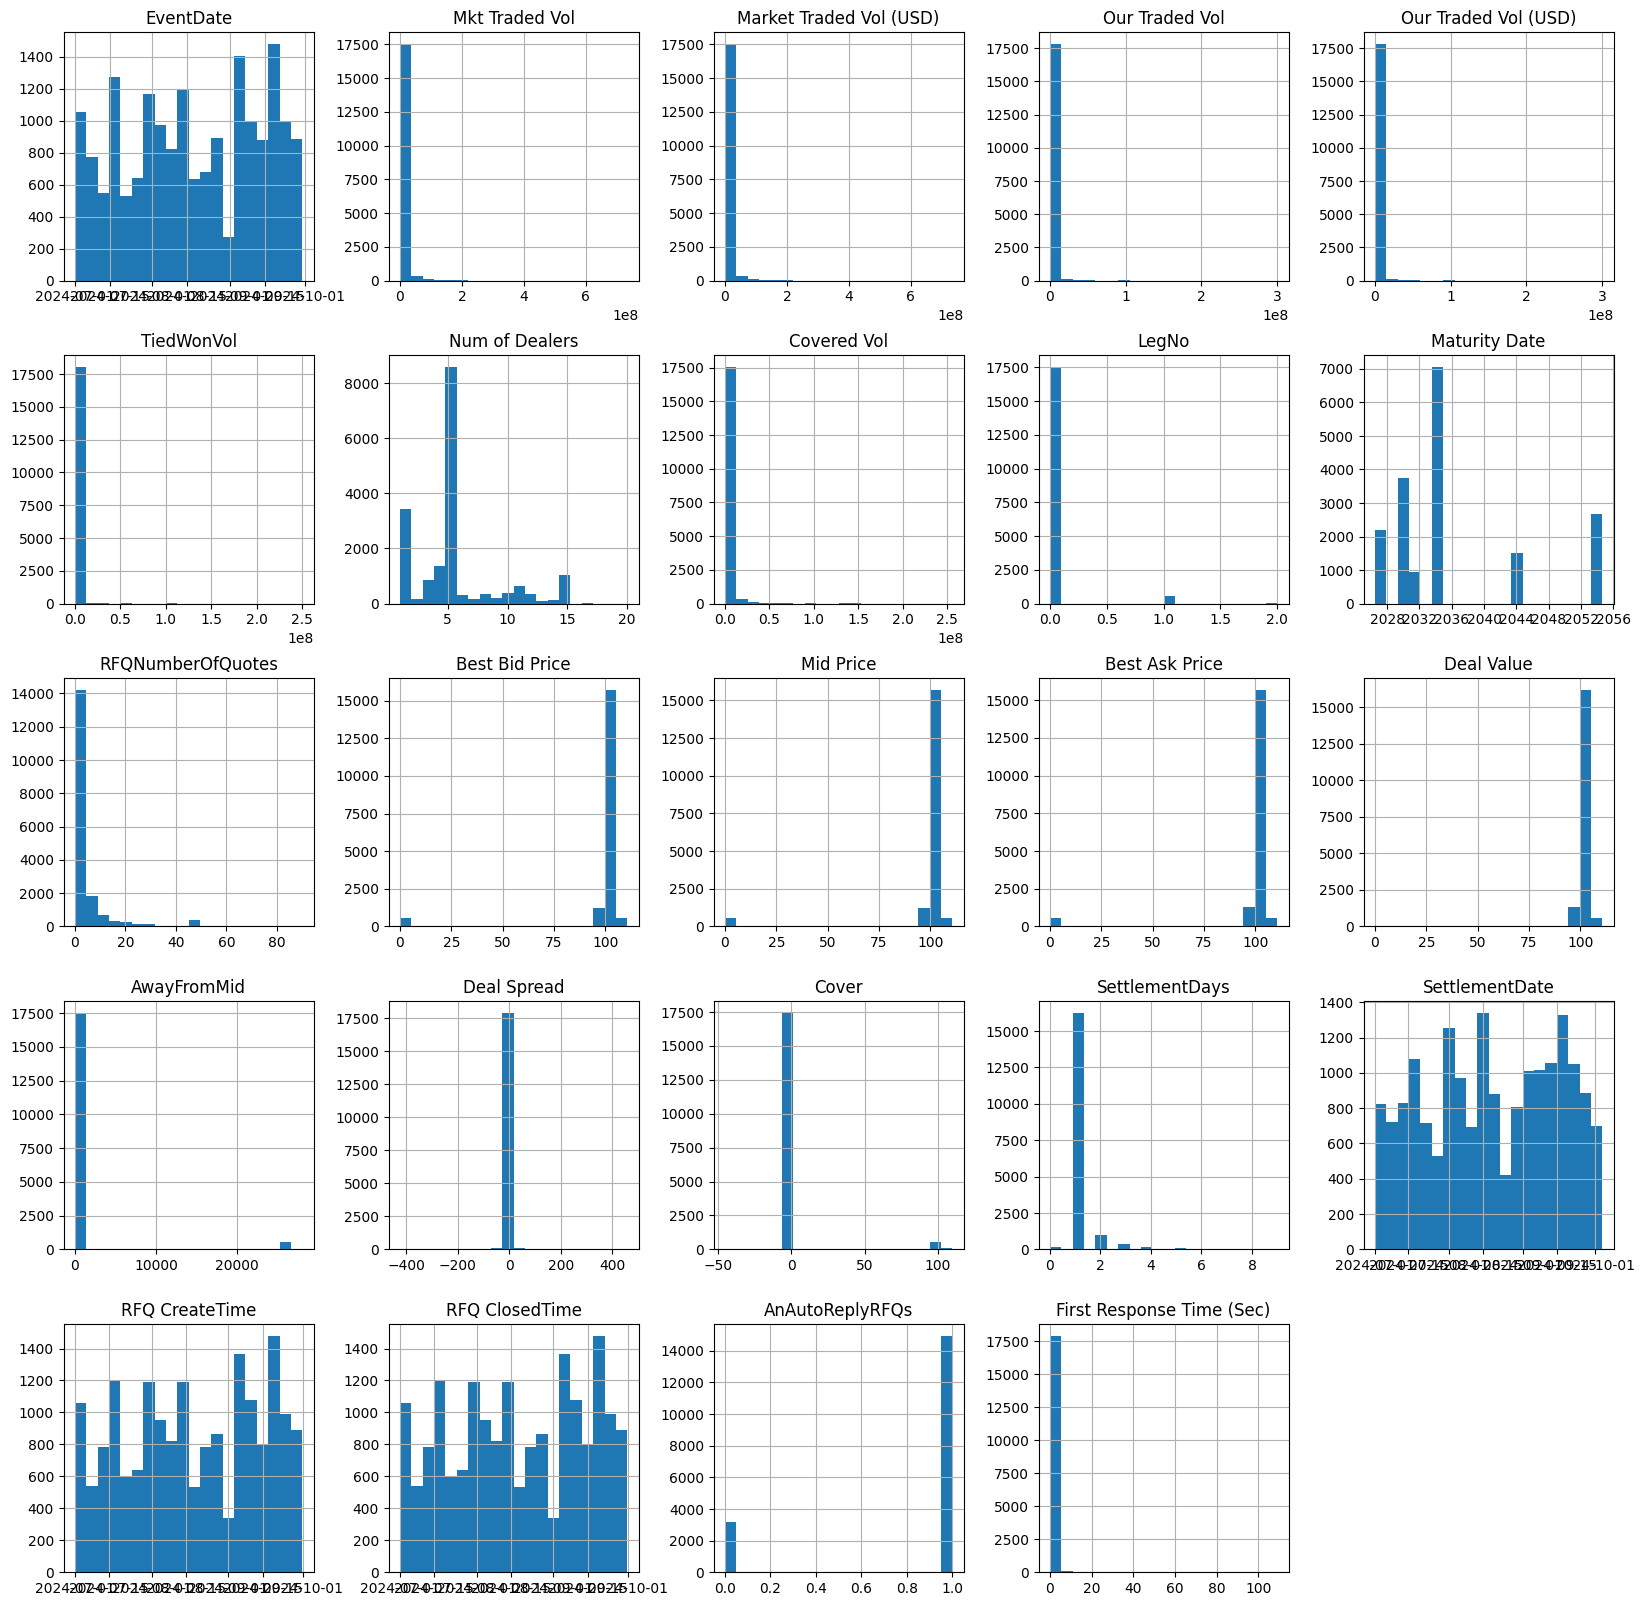

In [88]:
df.hist(bins=20, figsize=(20,20))
plt.show()

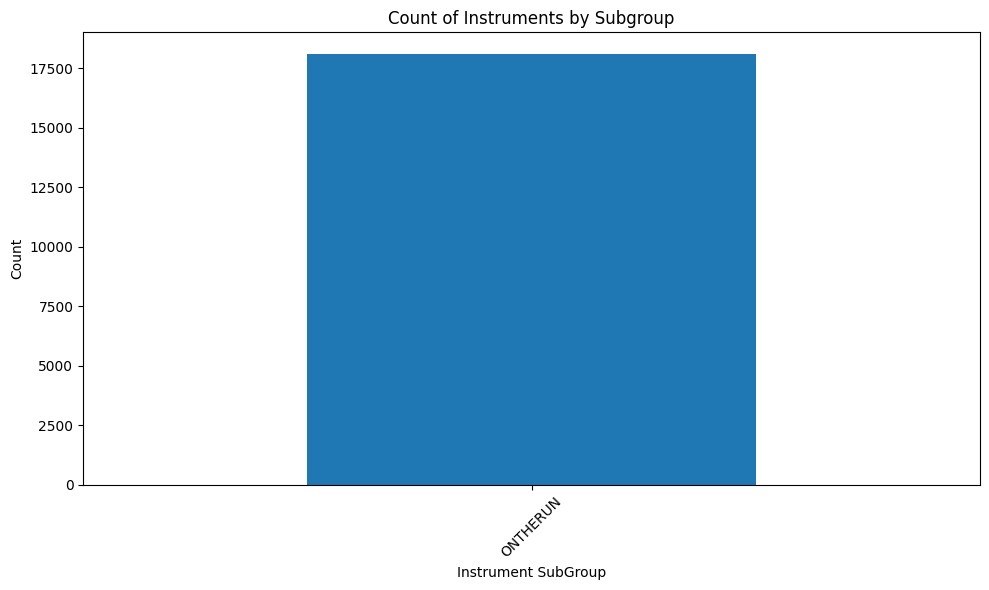

In [89]:
subgroup_counts = df['InstrumentSubGroup'].value_counts()

# Plot the bar chart
plt.figure(figsize=(10, 6))
subgroup_counts.plot(kind='bar')
plt.title('Count of Instruments by Subgroup')
plt.xlabel('Instrument SubGroup')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [90]:
subgroup_counts = df['Maturity Date'].value_counts()
subgroup_counts

Maturity Date
2034-08-15    4144
2034-05-15    2913
2054-08-15    1444
2029-07-31    1399
2029-08-31    1333
2054-05-15    1215
2029-06-30     862
2044-05-15     779
2044-08-15     737
2026-07-31     449
2027-08-15     406
2031-07-31     352
2026-08-31     340
2027-07-15     330
2031-08-31     330
2026-06-30     318
2031-06-30     215
2027-09-15     213
2029-09-30     142
2027-06-15      95
2026-09-30      47
2031-09-30      44
Name: count, dtype: int64

In [91]:
subgroup_counts = df['MaturityBucket'].value_counts()
subgroup_counts

MaturityBucket
10-30y    5778
7y-10y    5572
3y-5y     4060
5y-7y     1238
18m-2y    1003
2y-3y      456
Name: count, dtype: int64

In [92]:
subgroup_counts = df['Sector'].value_counts()
subgroup_counts

Sector
7-10 YR     7992
15-30 YR    4175
5-7 YR      3736
2-3 YR      1154
3-5 YR      1044
TIPS           6
Name: count, dtype: int64

In [93]:
df['Trader'].nunique()

7

In [94]:
subgroup_counts = df['SettlementDate'].value_counts()
subgroup_counts

SettlementDate
2024-08-15    784
2024-09-20    455
2024-09-06    420
2024-09-12    397
2024-09-19    391
             ... 
2024-08-13     85
2024-10-02     26
2024-07-01      3
2024-10-03      2
2024-10-04      1
Name: count, Length: 68, dtype: int64

In [95]:
df['Client'].nunique()

521

In [96]:
import pandas as pd

# Ensure EventDate is a datetime object
df['EventDate'] = pd.to_datetime(df['EventDate'])

# Group by Client and EventDate to calculate daily traded volume
daily_traded_volume = df.groupby(['Client', 'EventDate'])['Market Traded Vol (USD)'].sum().reset_index()

# Group by Client to calculate the mean traded volume
mean_traded_volume = daily_traded_volume.groupby('Client')['Market Traded Vol (USD)'].mean().reset_index()

# Rename the columns for clarity
mean_traded_volume.columns = ['Client', 'Mean Traded Volume (USD)']

# Sort by numeric value of the client number
mean_traded_volume['Client Number'] = mean_traded_volume['Client'].str.extract(r'(\d+)').astype(int)
mean_traded_volume = mean_traded_volume.sort_values(by='Client Number').drop(columns=['Client Number'])

# Format the mean traded volume to avoid scientific notation
mean_traded_volume['Mean Traded Volume (USD)'] = mean_traded_volume['Mean Traded Volume (USD)'].map('{:.2f}'.format)

# Display the result
mean_traded_volume

,Client,Mean Traded Volume (USD)
73,Client2,585000.00
138,Client3,10381400.00
205,Client4,58400000.00
282,Client5,2700000.00
357,Client6,206580717.24
...,...,...
501,Client792,460000.00
502,Client793,3800000.00
503,Client794,12000000.00
505,Client801,650000.00


Percentiles of Mean Traded Volume (USD):
25th Percentile: 1460000.00
50th Percentile (Median): 4575000.00
75th Percentile: 14223129.03


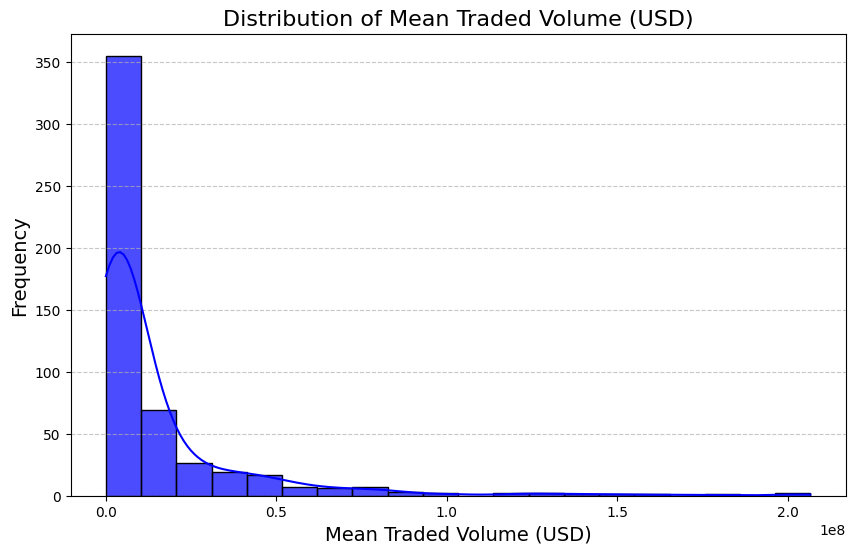

In [97]:
# Ensure the column is numeric
mean_traded_volume['Mean Traded Volume (USD)'] = pd.to_numeric(mean_traded_volume['Mean Traded Volume (USD)'])


# Calculate the 25th, 50th (median), and 75th percentiles
percentiles = mean_traded_volume['Mean Traded Volume (USD)'].quantile([0.25, 0.50, 0.75])

# Display the results
print("Percentiles of Mean Traded Volume (USD):")
print(f"25th Percentile: {percentiles[0.25]:.2f}")
print(f"50th Percentile (Median): {percentiles[0.50]:.2f}")
print(f"75th Percentile: {percentiles[0.75]:.2f}")

# Plot a histogram
plt.figure(figsize=(10, 6))
sns.histplot(mean_traded_volume['Mean Traded Volume (USD)'], bins=20, kde=True, color='blue', alpha=0.7)
plt.title('Distribution of Mean Traded Volume (USD)', fontsize=16)
plt.xlabel('Mean Traded Volume (USD)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [98]:
mean_traded_volume['Mean Traded Volume (USD)'] = pd.to_numeric(mean_traded_volume['Mean Traded Volume (USD)'])

all_client_mean = mean_traded_volume['Mean Traded Volume (USD)'].mean()

all_client_mean

14522715.333608445

## On-the-run VPIN

In [99]:
import pandas as pd

def calculate_vpin(df, threshold, rolling_window=10, volume_bucket_size = 0, column_order=None, row_order=None):
    """
    Calculate VPIN for clients and reorder columns and rows in the final output.

    Parameters:
    - df (pd.DataFrame): Input DataFrame with columns ['Client', 'EventDate', 'Buy/Sell', 'Market Traded Vol (USD)', 'Tier', 'MaturityBucket']
    - threshold (float): Threshold for VPIN filtering (e.g., > 0.5).
    - rolling_window (int): Rolling window size for VPIN calculation.
    - volume_bucket_size (int): Size of volume buckets for VPIN calculation. If 0, use daily volume.
    - column_order (list): Desired column order for the final output.
    - row_order (list): Desired row order for the final output.

    Returns:
    - percentage_clients_above_0_5 (pd.DataFrame): DataFrame of percentage clients above VPIN > threshold.
    """
    # Map buy/sell to numerical signs
    df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})

    # Lists to store client VPIN data
    client_names = []
    mean_vpin_values = []

    # Loop through each client
    for trader in df['Client'].unique():
        tmp_df = df[df['Client'] == trader]

        if volume_bucket_size > 0:
            # Group data into volume buckets
            tmp_df['Cumulative Volume'] = tmp_df['Market Traded Vol (USD)'].cumsum()
            tmp_df['Volume Bucket'] = (tmp_df['Cumulative Volume'] // volume_bucket_size).astype(int)
            
            # Aggregate volume bucket data
            bucket_volume = tmp_df.groupby(['Volume Bucket', 'Sign'])['Market Traded Vol (USD)'].sum().unstack(fill_value=0)
            bucket_volume = bucket_volume.rename(columns={1: 'Buy Volume', -1: 'Sell Volume'})
            
            if 'Buy Volume' not in bucket_volume.columns or 'Sell Volume' not in bucket_volume.columns:
                client_names.append(trader)
                mean_vpin_values.append(0)
                continue
            if (bucket_volume['Buy Volume'] == 0).all() or (bucket_volume['Sell Volume'] == 0).all():
                client_names.append(trader)
                mean_vpin_values.append(0)
                continue

            # Calculate Order Imbalance and VPIN for volume buckets
            bucket_volume['Order Imbalance'] = abs(bucket_volume['Buy Volume'] - bucket_volume['Sell Volume'])
            mean_bucket_volume = bucket_volume[['Buy Volume', 'Sell Volume']].sum(axis=1).mean()
            bucket_volume['VPIN'] = bucket_volume['Order Imbalance'].rolling(window=rolling_window).sum() / (rolling_window * mean_bucket_volume)
            mean_vpin = bucket_volume['VPIN'].mean()
        else:
            # Aggregate daily buy/sell volumes
            daily_volume = tmp_df.groupby([tmp_df['EventDate'].dt.date, 'Sign'])['Market Traded Vol (USD)'].sum().unstack(fill_value=0)
            daily_volume = daily_volume.rename(columns={1: 'Buy Volume', -1: 'Sell Volume'})

            if 'Buy Volume' not in daily_volume.columns or 'Sell Volume' not in daily_volume.columns:
                client_names.append(trader)
                mean_vpin_values.append(0)
                continue
            if (daily_volume['Buy Volume'] == 0).all() or (daily_volume['Sell Volume'] == 0).all():
                client_names.append(trader)
                mean_vpin_values.append(0)
                continue

            # Calculate Order Imbalance and VPIN for daily volumes
            daily_volume['Order Imbalance'] = abs(daily_volume['Buy Volume'] - daily_volume['Sell Volume'])
            mean_daily_volume = daily_volume[['Buy Volume', 'Sell Volume']].sum(axis=1).mean()
            daily_volume['VPIN'] = daily_volume['Order Imbalance'].rolling(window=rolling_window).sum() / (rolling_window * mean_daily_volume)
            
            mean_vpin = daily_volume['VPIN'].mean()

        # Store results for the client
        client_names.append(trader)
        mean_vpin_values.append(mean_vpin)

    # Create a DataFrame of mean VPIN values
    mean_vpin_df = pd.DataFrame({'Client': client_names, 'Mean VPIN': mean_vpin_values})

    # Merge mean VPIN values back into the original DataFrame
    df = df.merge(mean_vpin_df, on='Client', how='left')

    # Filter clients with VPIN > threshold
    df_above_threshold = df[df['Mean VPIN'] > threshold]

    # Calculate unique clients per Tier and MaturityBucket
    unique_clients_above_threshold = df_above_threshold.groupby(['Tier', 'MaturityBucket'])['Client'].nunique()
    total_unique_clients = df.groupby(['Tier', 'MaturityBucket'])['Client'].nunique()

    # Calculate percentage of clients with VPIN > threshold
    percentage_clients_above_threshold = (unique_clients_above_threshold / total_unique_clients).unstack(fill_value=0).round(2)
    percentage_clients_above_threshold = percentage_clients_above_threshold.fillna(0)

    # Reorder columns and rows if specified
    if column_order:
        percentage_clients_above_threshold = percentage_clients_above_threshold[column_order]
    if row_order:
        percentage_clients_above_threshold = percentage_clients_above_threshold.reindex(row_order)

    return percentage_clients_above_threshold

In [100]:
# Define desired column and row orders
column_order = ['18m-2y', '2y-3y', '3y-5y', '5y-7y', '7y-10y', '10-30y']
row_order = ['TIER1', 'TIER2', 'TIER3', 'TIER9', 'TierGOLD', 'TierINTERNAL', 'MANUAL']

# Call the function
percentage_clients_above_0_5 = calculate_vpin(df, threshold = 0.5, rolling_window=10, volume_bucket_size = 0, column_order=column_order, row_order=row_order)

# Display the output
percentage_clients_above_0_5

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})


MaturityBucket,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,
TIER1,0.70,0.70,0.71,0.70,0.61,0.66
TIER2,0.31,0.41,0.33,0.38,0.27,0.35
TIER3,1.00,1.00,1.00,0.67,0.67,0.67
TIER9,0.40,0.00,0.29,0.20,0.00,0.17
TierGOLD,1.00,1.00,0.50,0.50,0.50,0.50
TierINTERNAL,0.00,0.00,0.00,0.00,0.00,0.00
MANUAL,0.50,0.67,0.37,0.43,0.30,0.32


## Threshold

### threshold = 0.3

In [101]:
# Call the function
percentage_clients = calculate_vpin(df, threshold = 0.3, rolling_window=10, volume_bucket_size = 0, column_order=column_order, row_order=row_order)

# Display the output
percentage_clients

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})


MaturityBucket,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,
TIER1,0.70,0.74,0.71,0.70,0.64,0.66
TIER2,0.41,0.52,0.40,0.48,0.33,0.41
TIER3,1.00,1.00,1.00,0.67,0.67,0.67
TIER9,1.00,0.50,0.71,0.80,0.75,0.67
TierGOLD,1.00,1.00,0.50,0.50,0.50,0.50
TierINTERNAL,0.50,1.00,0.50,0.50,0.33,0.33
MANUAL,0.56,0.83,0.48,0.57,0.39,0.41


### threshold = 0.5

In [102]:
# Call the function
percentage_clients = calculate_vpin(df, threshold = 0.5, rolling_window=10, volume_bucket_size = 0, column_order=column_order, row_order=row_order)

# Display the output
percentage_clients

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})


MaturityBucket,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,
TIER1,0.70,0.70,0.71,0.70,0.61,0.66
TIER2,0.31,0.41,0.33,0.38,0.27,0.35
TIER3,1.00,1.00,1.00,0.67,0.67,0.67
TIER9,0.40,0.00,0.29,0.20,0.00,0.17
TierGOLD,1.00,1.00,0.50,0.50,0.50,0.50
TierINTERNAL,0.00,0.00,0.00,0.00,0.00,0.00
MANUAL,0.50,0.67,0.37,0.43,0.30,0.32


### threshold = 0.7

In [103]:
# Call the function
percentage_clients = calculate_vpin(df, threshold = 0.7, rolling_window=10, volume_bucket_size = 0, column_order=column_order, row_order=row_order)

# Display the output
percentage_clients

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})


MaturityBucket,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,
TIER1,0.59,0.57,0.53,0.52,0.45,0.50
TIER2,0.17,0.24,0.20,0.22,0.17,0.22
TIER3,1.00,1.00,1.00,0.67,0.67,0.67
TIER9,0.20,0.00,0.14,0.20,0.00,0.00
TierGOLD,0.00,0.00,0.00,0.00,0.00,0.00
TierINTERNAL,0.00,0.00,0.00,0.00,0.00,0.00
MANUAL,0.44,0.58,0.33,0.38,0.27,0.30


# Rolling Window Length

### rolling window length = 5

In [104]:
# Call the function
percentage_clients = calculate_vpin(df, threshold = 0.5, rolling_window=5, volume_bucket_size = 0, column_order=column_order, row_order=row_order)

# Display the output
percentage_clients

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})


MaturityBucket,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,
TIER1,0.85,0.83,0.82,0.79,0.70,0.79
TIER2,0.42,0.54,0.47,0.52,0.41,0.48
TIER3,1.00,1.00,1.00,0.67,0.67,0.67
TIER9,0.60,0.00,0.57,0.40,0.25,0.50
TierGOLD,1.00,1.00,0.50,0.50,0.50,0.50
TierINTERNAL,0.00,0.00,0.00,0.00,0.33,0.33
MANUAL,0.61,0.75,0.44,0.67,0.48,0.49


### rolling window length = 10

In [105]:
# Call the function
percentage_clients = calculate_vpin(df, threshold = 0.5, rolling_window=10, volume_bucket_size = 0, column_order=column_order, row_order=row_order)

# Display the output
percentage_clients

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})


MaturityBucket,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,
TIER1,0.70,0.70,0.71,0.70,0.61,0.66
TIER2,0.31,0.41,0.33,0.38,0.27,0.35
TIER3,1.00,1.00,1.00,0.67,0.67,0.67
TIER9,0.40,0.00,0.29,0.20,0.00,0.17
TierGOLD,1.00,1.00,0.50,0.50,0.50,0.50
TierINTERNAL,0.00,0.00,0.00,0.00,0.00,0.00
MANUAL,0.50,0.67,0.37,0.43,0.30,0.32


### rolling window length = 15

In [106]:
# Call the function
percentage_clients = calculate_vpin(df, threshold = 0.5, rolling_window=15, volume_bucket_size = 0, column_order=column_order, row_order=row_order)

# Display the output
percentage_clients

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})


MaturityBucket,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,
TIER1,0.67,0.61,0.61,0.58,0.52,0.61
TIER2,0.25,0.33,0.24,0.27,0.21,0.25
TIER3,1.00,1.00,1.00,0.67,0.67,0.67
TIER9,0.60,0.00,0.43,0.40,0.25,0.33
TierGOLD,1.00,1.00,0.50,0.50,0.50,0.50
TierINTERNAL,0.00,0.00,0.00,0.00,0.00,0.00
MANUAL,0.33,0.50,0.26,0.33,0.18,0.19


# Volume Bucket Size

## volume bucket size = 100000

In [107]:
# Call the function
percentage_clients = calculate_vpin(df, threshold = 0.5, rolling_window=10, volume_bucket_size = 100000, column_order=column_order, row_order=row_order)

# Display the output
percentage_clients

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['Cumulative Volume'] = tmp_df['Market Traded Vol (USD)'].cumsum()
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:32: SettingWithCopyWarning: 
A value is trying to be s

MaturityBucket,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,
TIER1,0.74,0.83,0.76,0.76,0.73,0.71
TIER2,0.48,0.57,0.47,0.55,0.40,0.48
TIER3,1.00,1.00,1.00,0.67,0.67,0.67
TIER9,1.00,1.00,0.86,1.00,1.00,0.83
TierGOLD,1.00,1.00,0.50,0.50,0.50,0.50
TierINTERNAL,1.00,1.00,1.00,1.00,0.67,0.67
MANUAL,0.56,0.83,0.48,0.62,0.42,0.41


## volume bucket size = 500000

In [108]:
# Call the function
percentage_clients = calculate_vpin(df, threshold = 0.5, rolling_window=10, volume_bucket_size = 500000, column_order=column_order, row_order=row_order)

# Display the output
percentage_clients

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['Cumulative Volume'] = tmp_df['Market Traded Vol (USD)'].cumsum()
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:32: SettingWithCopyWarning: 
A value is trying to be s

MaturityBucket,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,
TIER1,0.74,0.83,0.76,0.76,0.73,0.71
TIER2,0.48,0.57,0.47,0.55,0.40,0.48
TIER3,1.00,1.00,1.00,0.67,0.67,0.67
TIER9,1.00,1.00,0.86,1.00,1.00,0.83
TierGOLD,1.00,1.00,0.50,0.50,0.50,0.50
TierINTERNAL,1.00,1.00,1.00,1.00,0.67,0.67
MANUAL,0.56,0.83,0.48,0.62,0.42,0.41


## volume bucket size = 1000000

In [109]:
# Call the function
percentage_clients = calculate_vpin(df, threshold = 0.5, rolling_window=10, volume_bucket_size = 1000000, column_order=column_order, row_order=row_order)

# Display the output
percentage_clients

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['Cumulative Volume'] = tmp_df['Market Traded Vol (USD)'].cumsum()
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:32: SettingWithCopyWarning: 
A value is trying to be s

MaturityBucket,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,
TIER1,0.74,0.83,0.76,0.76,0.73,0.71
TIER2,0.47,0.57,0.47,0.55,0.39,0.48
TIER3,1.00,1.00,1.00,0.67,0.67,0.67
TIER9,1.00,0.50,0.71,0.80,0.75,0.67
TierGOLD,1.00,1.00,0.50,0.50,0.50,0.50
TierINTERNAL,1.00,1.00,1.00,1.00,0.67,0.67
MANUAL,0.44,0.75,0.41,0.57,0.36,0.35


## volume bucket size = 5000000

In [110]:
# Call the function
percentage_clients = calculate_vpin(df, threshold = 0.5, rolling_window=10, volume_bucket_size = 5000000, column_order=column_order, row_order=row_order)

# Display the output
percentage_clients

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['Cumulative Volume'] = tmp_df['Market Traded Vol (USD)'].cumsum()
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_74342/1147787548.py:32: SettingWithCopyWarning: 
A value is trying to be s

MaturityBucket,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,10-30y
Tier,,,,,,
TIER1,0.74,0.78,0.74,0.73,0.68,0.68
TIER2,0.40,0.49,0.38,0.45,0.32,0.38
TIER3,1.00,1.00,1.00,0.67,0.67,0.67
TIER9,1.00,0.50,0.71,0.80,0.75,0.67
TierGOLD,1.00,1.00,0.50,0.50,0.50,0.50
TierINTERNAL,1.00,1.00,1.00,1.00,0.67,0.67
MANUAL,0.39,0.67,0.33,0.43,0.30,0.27
